In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

In [5]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0

    def predict(self, X):
        return np.where(np.dot(X, self.w) + self.b >= 0, 1, 0)

In [7]:
def plot_boundary(X, y, w, b, title, filename):
    plt.figure(figsize=(6,6))

    plt.scatter(X[y==0][:,0], X[y==0][:,1], c='red', s=100, label='Class 0')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], c='blue', s=100, label='Class 1')

    x = np.linspace(-0.5,1.5,200)

    if abs(w[1]) > 1e-8:
        y_line = -(w[0]*x + b)/w[1]
        plt.plot(x,y_line,'k',linewidth=2)
    elif abs(w[0]) > 1e-8:
        plt.axvline(-b/w[0],color='k',linewidth=2)

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.savefig(f"images/{filename}.png",dpi=600,bbox_inches="tight")
    plt.show()

In [8]:
def train_gate(X, y, gate_name, lr=0.1, epochs=20):
    model = Perceptron(lr, epochs)
    model.w = np.zeros(X.shape[1])
    model.b = 0

    update = 1

    for epoch in range(epochs):
        errors = 0

        for xi, target in zip(X, y):

            pred = 1 if np.dot(model.w, xi) + model.b >= 0 else 0

            if pred != target:
                delta = lr * (target - pred)

                model.w += delta * xi
                model.b += delta

                print(f"Update {update}")
                print("Input :", xi)
                print("Target:", target)
                print("Prediction:", pred)
                print("Weights:", model.w)
                print("Bias:", model.b)
                print()

                plot_boundary(
                    X,
                    y,
                    model.w,
                    model.b,
                    f"{gate_name} Update {update}",
                    f"{gate_name.lower()}_update_{update}"
                )

                update += 1
                errors += 1

        if errors == 0:
            break

    print("Final Weights:", model.w)
    print("Final Bias:", model.b)

    plot_boundary(
        X,
        y,
        model.w,
        model.b,
        f"{gate_name} Final Decision Boundary",
        f"{gate_name.lower()}_final"
    )

    preds = model.predict(X)

    print("\nPredictions")
    for inp,p in zip(X,preds):
        print(inp,"->",p)

Update 1
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0. 0.]
Bias: -0.1



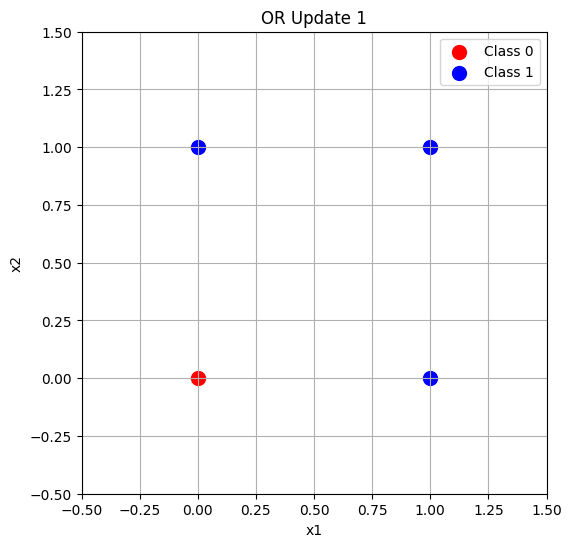

Update 2
Input : [0 1]
Target: 1
Prediction: 0
Weights: [0.  0.1]
Bias: 0.0



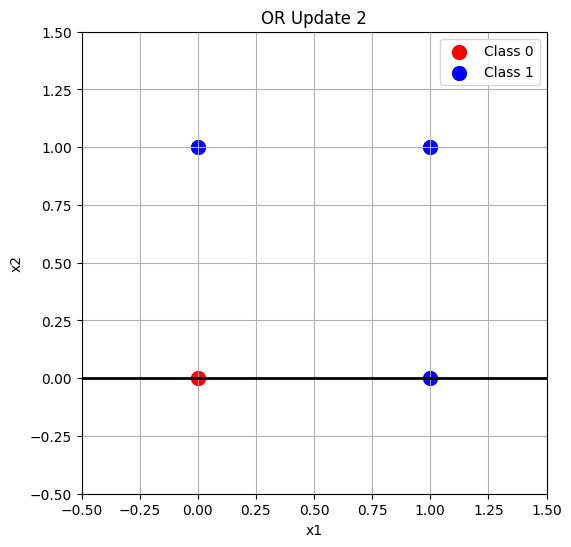

Update 3
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0.  0.1]
Bias: -0.1



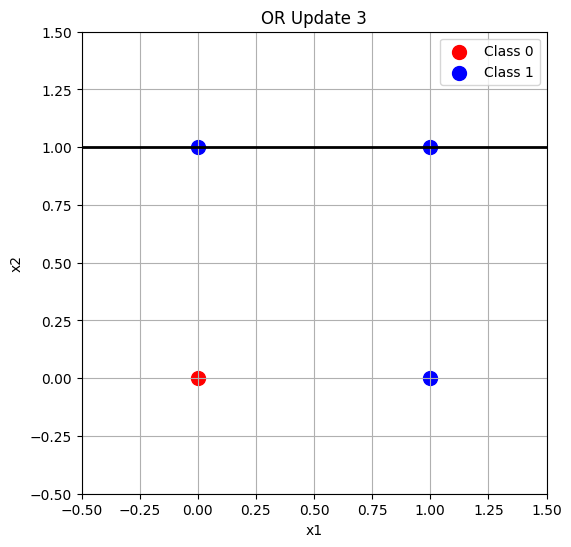

Update 4
Input : [1 0]
Target: 1
Prediction: 0
Weights: [0.1 0.1]
Bias: 0.0



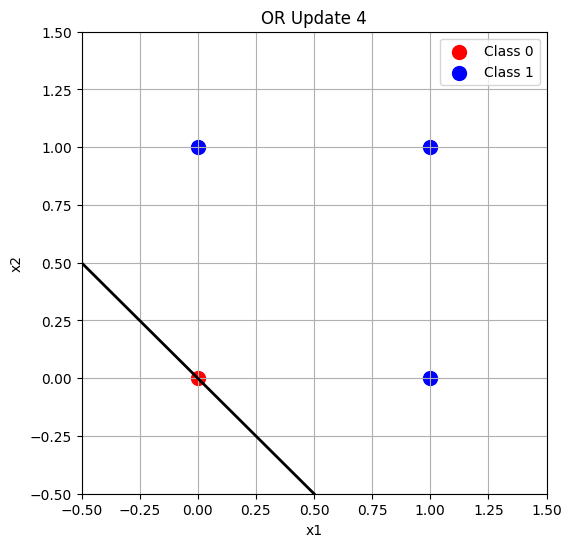

Update 5
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0.1 0.1]
Bias: -0.1



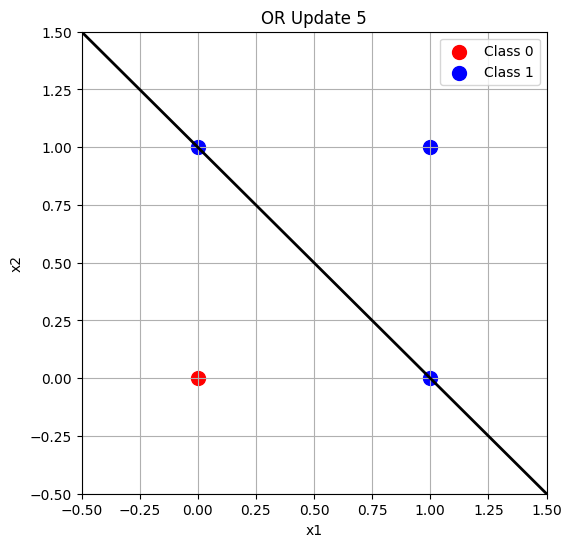

Final Weights: [0.1 0.1]
Final Bias: -0.1


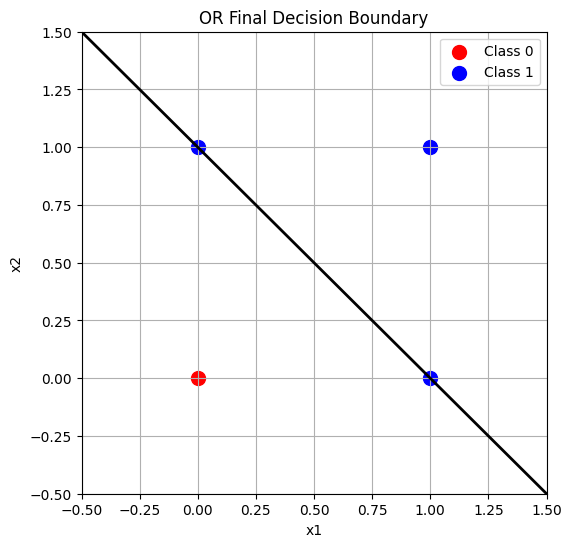


Predictions
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


In [9]:
# OR gate
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

train_gate(X_or, y_or, "OR")

Update 1
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0. 0.]
Bias: -0.1



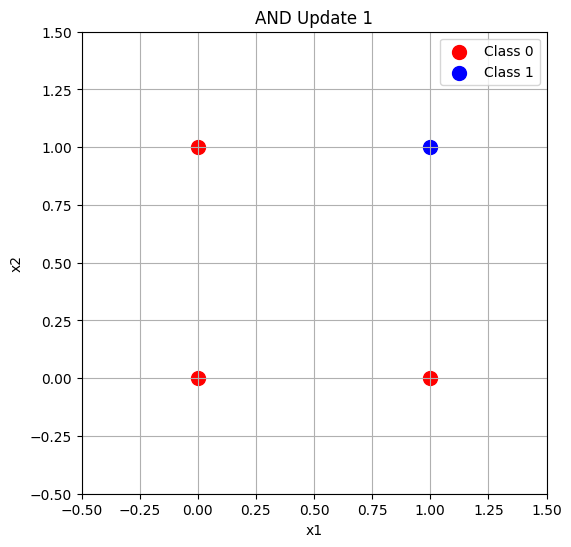

Update 2
Input : [1 1]
Target: 1
Prediction: 0
Weights: [0.1 0.1]
Bias: 0.0



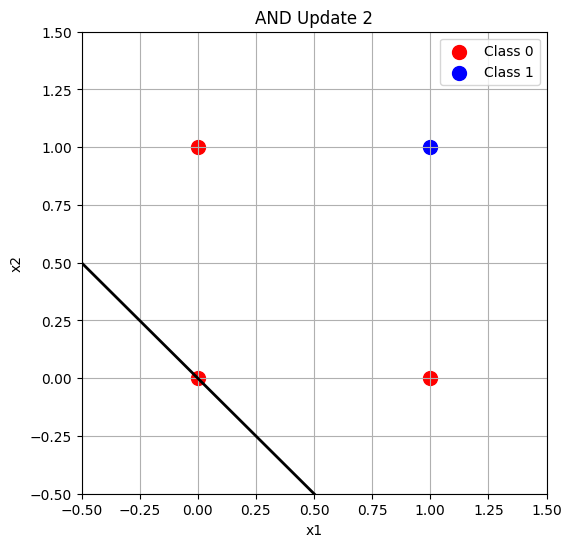

Update 3
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0.1 0.1]
Bias: -0.1



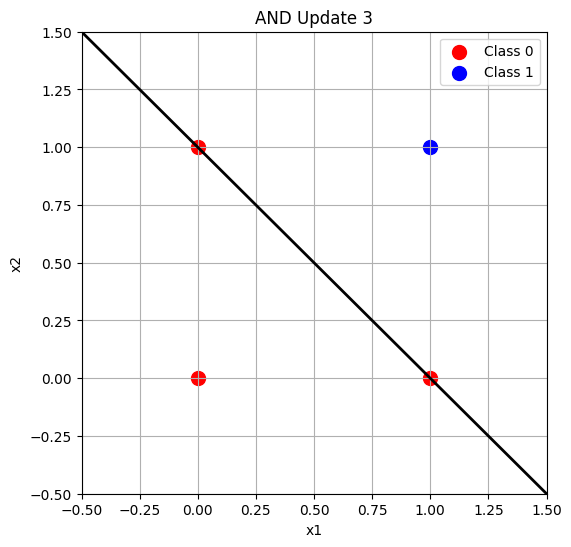

Update 4
Input : [0 1]
Target: 0
Prediction: 1
Weights: [0.1 0. ]
Bias: -0.2



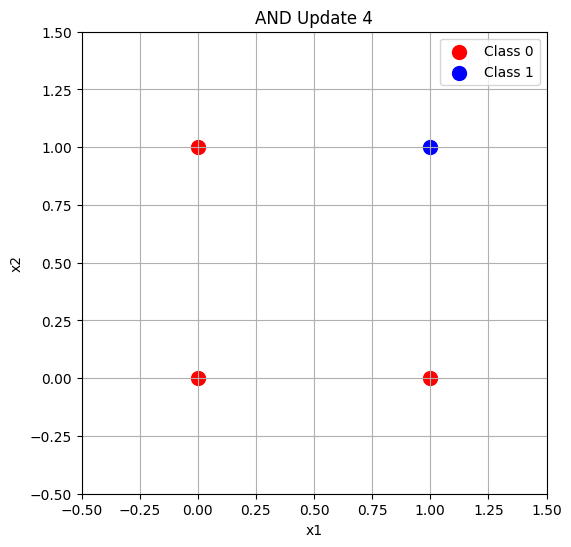

Update 5
Input : [1 1]
Target: 1
Prediction: 0
Weights: [0.2 0.1]
Bias: -0.1



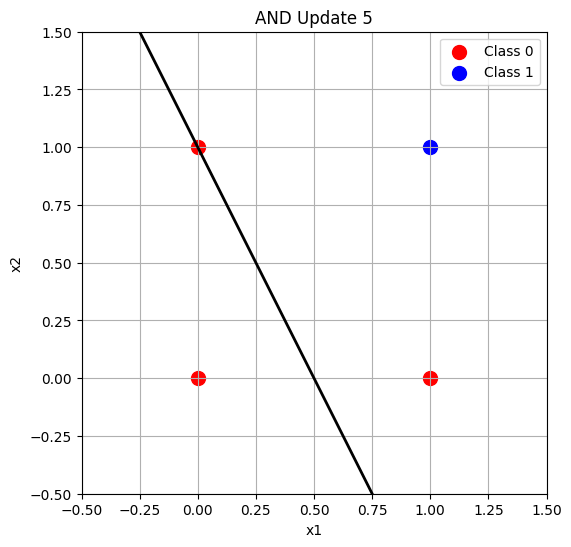

Update 6
Input : [0 1]
Target: 0
Prediction: 1
Weights: [0.2 0. ]
Bias: -0.2



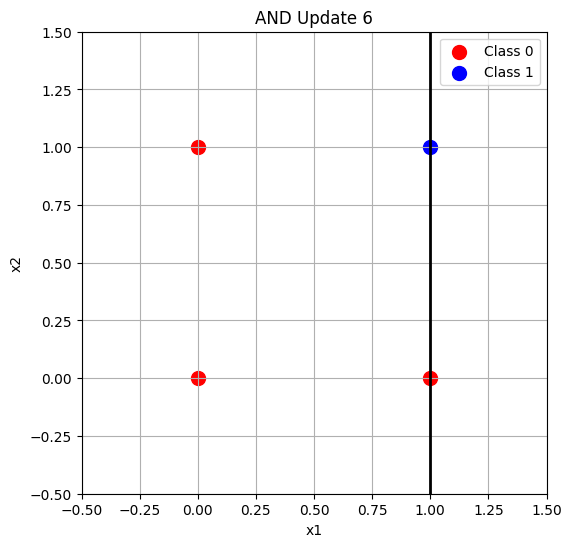

Update 7
Input : [1 0]
Target: 0
Prediction: 1
Weights: [0.1 0. ]
Bias: -0.30000000000000004



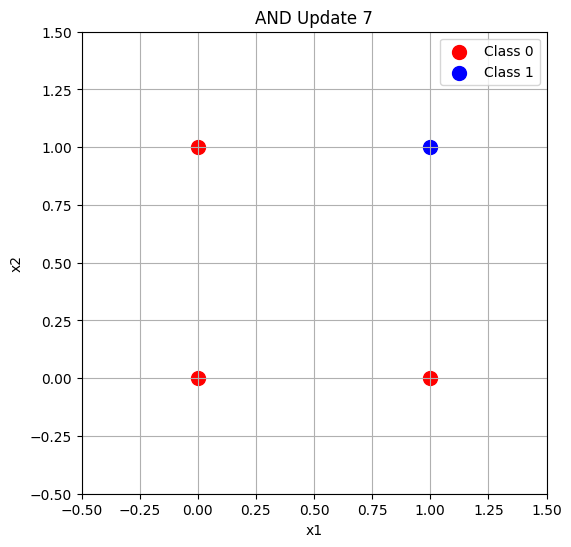

Update 8
Input : [1 1]
Target: 1
Prediction: 0
Weights: [0.2 0.1]
Bias: -0.20000000000000004



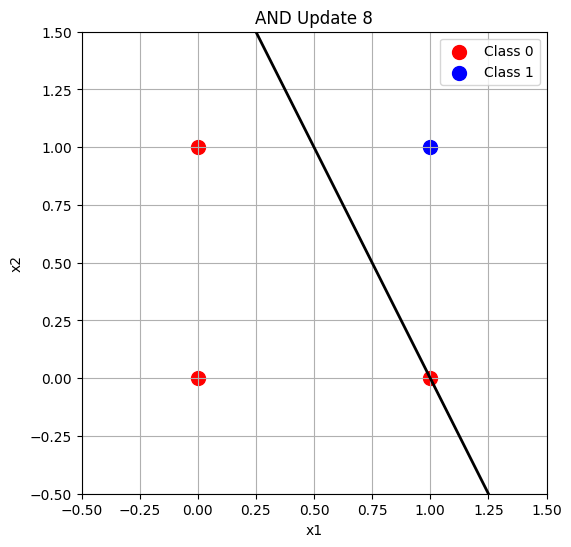

Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004


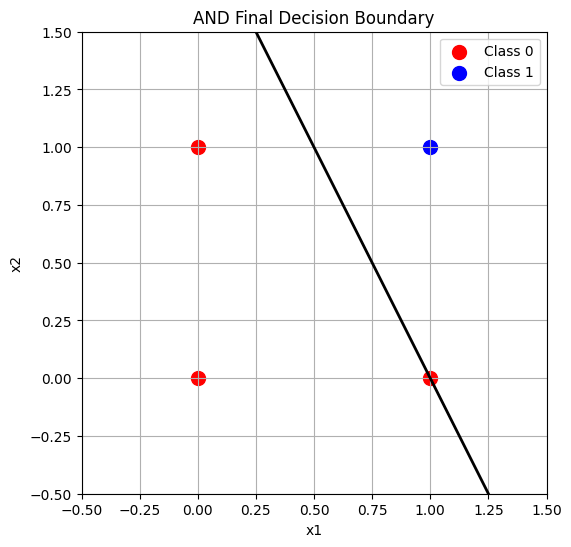


Predictions
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


In [10]:
# AND gate
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

train_gate(X_and, y_and, "AND")

Update 1
Input: [1]
Target: 0
Prediction: 1
Weight: [-0.1]
Bias: -0.1



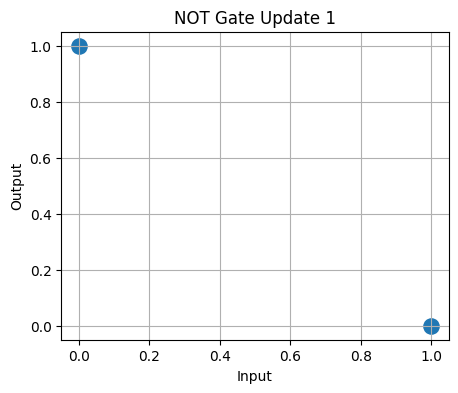

Update 2
Input: [0]
Target: 1
Prediction: 0
Weight: [-0.1]
Bias: 0.0



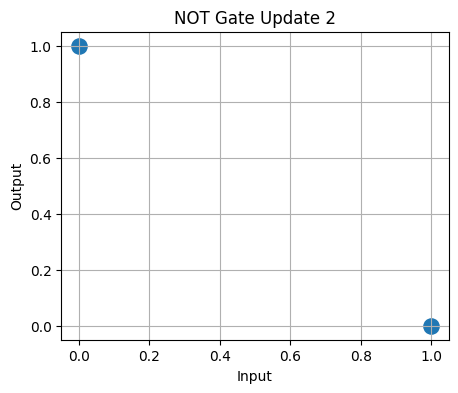

Final Weight: [-0.1]
Final Bias: 0.0

Predictions
[0] -> 1
[1] -> 0


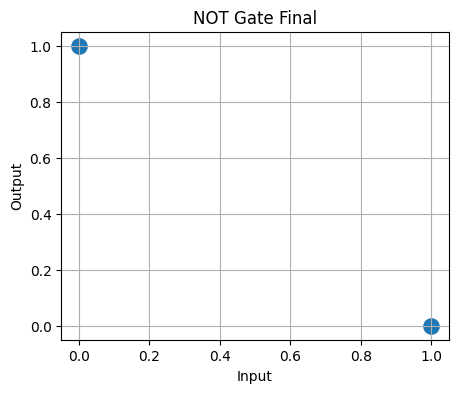

In [11]:
# NOT gate
X_not = np.array([[0],[1]])
y_not = np.array([1,0])

w = np.zeros(1)
b = 0
lr = 0.1

update = 1

for epoch in range(20):
    errors = 0

    for xi,target in zip(X_not,y_not):

        pred = 1 if np.dot(w,xi)+b>=0 else 0

        if pred!=target:

            delta = lr*(target-pred)
            w += delta*xi
            b += delta

            print(f"Update {update}")
            print("Input:",xi)
            print("Target:",target)
            print("Prediction:",pred)
            print("Weight:",w)
            print("Bias:",b)
            print()

            plt.figure(figsize=(5,4))
            plt.scatter(X_not,y_not,s=120)
            plt.xlabel("Input")
            plt.ylabel("Output")
            plt.title(f"NOT Gate Update {update}")
            plt.grid(True)
            plt.savefig(f"images/not_update_{update}.png",dpi=600,bbox_inches="tight")
            plt.show()

            update += 1
            errors += 1

    if errors==0:
        break

print("Final Weight:",w)
print("Final Bias:",b)

preds = np.where(np.dot(X_not,w)+b>=0,1,0)

print("\nPredictions")
for i,p in zip(X_not,preds):
    print(i,"->",p)

plt.figure(figsize=(5,4))
plt.scatter(X_not,y_not,s=120)
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("NOT Gate Final")
plt.grid(True)
plt.savefig("images/not_final.png",dpi=600,bbox_inches="tight")
plt.show()